# Лабораторна робота №4

Виконавець:  <b>Потєхіна Валерія Ігорівна</b>, група <b>К-27</b>
<br> Викладач: <b>Скибицький М.</b>

## Задача 1

У завданні 2 лабораторної роботи №1 за датами створення файлів для кожного місяця, **починаючи з вересня 2024-го року**, було знайдено таку інформацію:

- кількість файлів з розширеннями з "білого списку",
- їх сумарний розмір у байтах,
- кількість їх рядків (враховувати тільки для файлів категорії C; білі та порожні рядки не рахувати),
- середній розмір.

**Для кожної характеристики по місяцях побудувати:**
- графік,
- графік з накопиченням,
- стовпчикову діаграму,
- стовпчикову діаграму з накопиченням.

Графіки розташувати **на одному зображенні**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Підготуємо дані: для цього приведемо стовпець з кількістю рядків до числового формату та створимо єдиний формат дати (РРРР-ММ) для зручного відображення на осі абсцис.

In [2]:
df = pd.read_csv('lab1_1.csv')

In [3]:
df['lines'] = pd.to_numeric(df['lines'], errors='coerce').fillna(0)
df['date'] = df['year'].astype(str) + '-' + df['mon'].astype(str).str.zfill(2)
df_filtered = df[((df['year'] == 2024) & (df['mon'] >= 9)) | (df['year'] > 2024)]
print("Дати після фільтрації:", sorted(df_filtered['date'].unique()))

Дати після фільтрації: ['2024-10', '2024-11', '2025-02', '2025-03', '2025-05', '2025-10', '2026-02']


In [4]:
size_sum = df_filtered.groupby(['date', 'ext'])['size'].sum().reset_index()
cnt_sum = df_filtered.groupby(['date', 'ext'])['cnt'].sum().reset_index()

Об'єднуємо та обчислюємо середній розмір

In [5]:
avg_size_df = size_sum.merge(cnt_sum, on=['date', 'ext'])
avg_size_df['avg_size'] = avg_size_df['size'] / avg_size_df['cnt']
avg_size_df = avg_size_df[['date', 'ext', 'avg_size']]

In [6]:
df_filtered_with_avg = df_filtered.merge(avg_size_df, on=['date', 'ext'], how='left')

Створимо універсальну функцію plot_characteristic для створення зображення із сіткою 2x2.

In [7]:
def plot_characteristic(dataframe, values_col, title_base):
    pivot_df = dataframe.pivot_table(
        index='date', columns='ext',
        values=values_col, aggfunc='sum', fill_value=0
    )
    
    pivot_df = pivot_df.reindex(sorted(pivot_df.index))
    
    x = pivot_df.index.tolist()
    labels = pivot_df.columns.tolist()
    y_stack = [pivot_df[ext].values for ext in labels]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{title_base} по місяцях (з вересня 2024)', fontsize=16, fontweight='bold')

    for ext in labels:
        axes[0, 0].plot(x, pivot_df[ext], marker='o', label=ext)
    axes[0, 0].set_title('Графік (лінійний)')
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].set_ylabel(title_base)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend(loc='best', fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].stackplot(range(len(x)), y_stack, labels=labels)
    axes[0, 1].set_title('Графік з накопиченням')
    axes[0, 1].set_xlabel('Дата')
    axes[0, 1].set_ylabel(title_base)
    axes[0, 1].set_xticks(range(len(x)))
    axes[0, 1].set_xticklabels(x, rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    x_indexes = np.arange(len(x))
    width = 0.8 / len(labels) if len(labels) > 0 else 0.8
    for i, ext in enumerate(labels):
        axes[1, 0].bar(x_indexes + i * width - (len(labels)-1)*width/2,
                       pivot_df[ext], width=width, label=ext)
    axes[1, 0].set_xticks(x_indexes)
    axes[1, 0].set_xticklabels(x, rotation=45)
    axes[1, 0].set_title('Стовпчикова діаграма')
    axes[1, 0].set_xlabel('Дата')
    axes[1, 0].set_ylabel(title_base)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    bottom = np.zeros(len(x))
    for ext in labels:
        axes[1, 1].bar(x, pivot_df[ext], bottom=bottom, label=ext)
        bottom += pivot_df[ext].values
    axes[1, 1].set_title('Стовпчикова діаграма з накопиченням')
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].set_ylabel(title_base)
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    handles, plot_labels = axes[1, 1].get_legend_handles_labels()
    if handles:
        fig.legend(handles, plot_labels, loc='center right',
                   bbox_to_anchor=(1.12, 0.5), title='Розширення')
    
    plt.tight_layout()
    plt.savefig(f'plot_{values_col}.png', dpi=150, bbox_inches='tight')
    plt.show()

Викличемо функцію plot_characteristic для генерації та збереження візуалізацій за чотирма основними характеристиками.

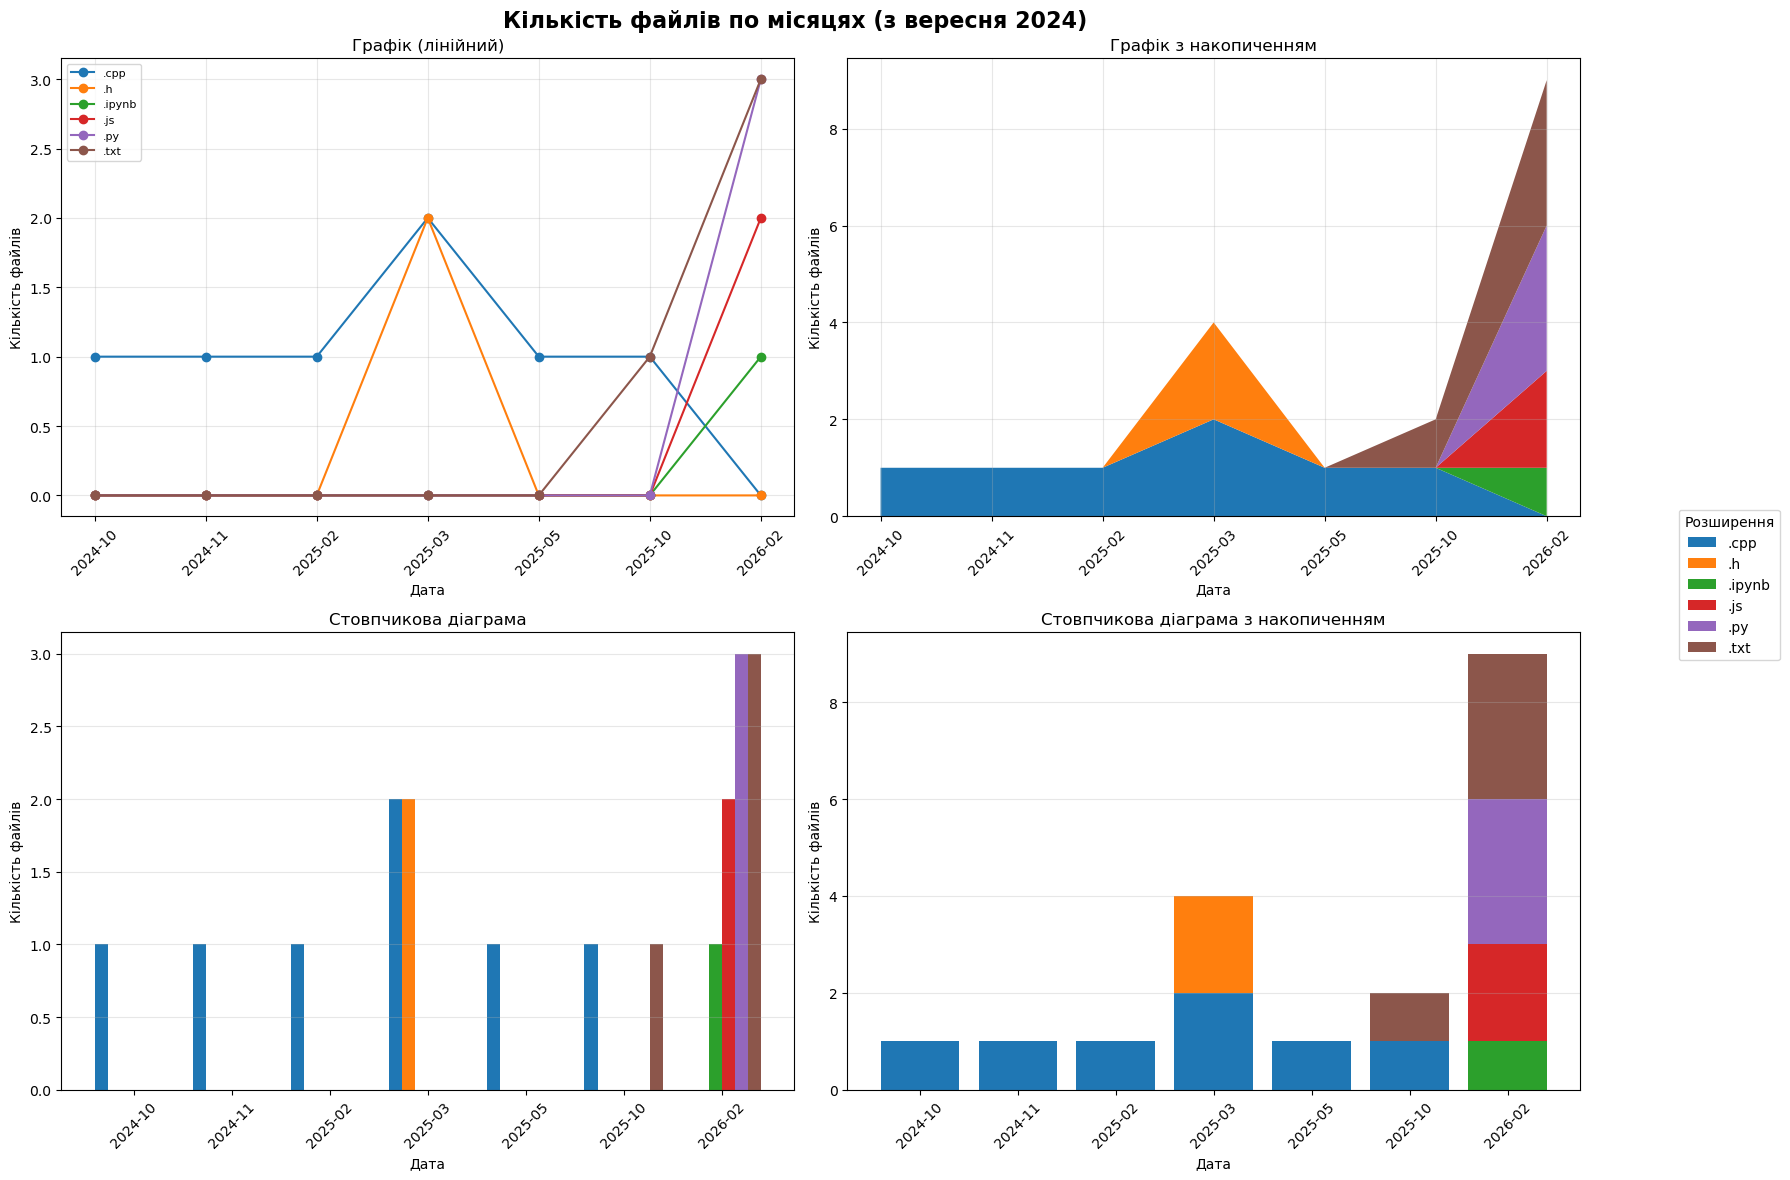

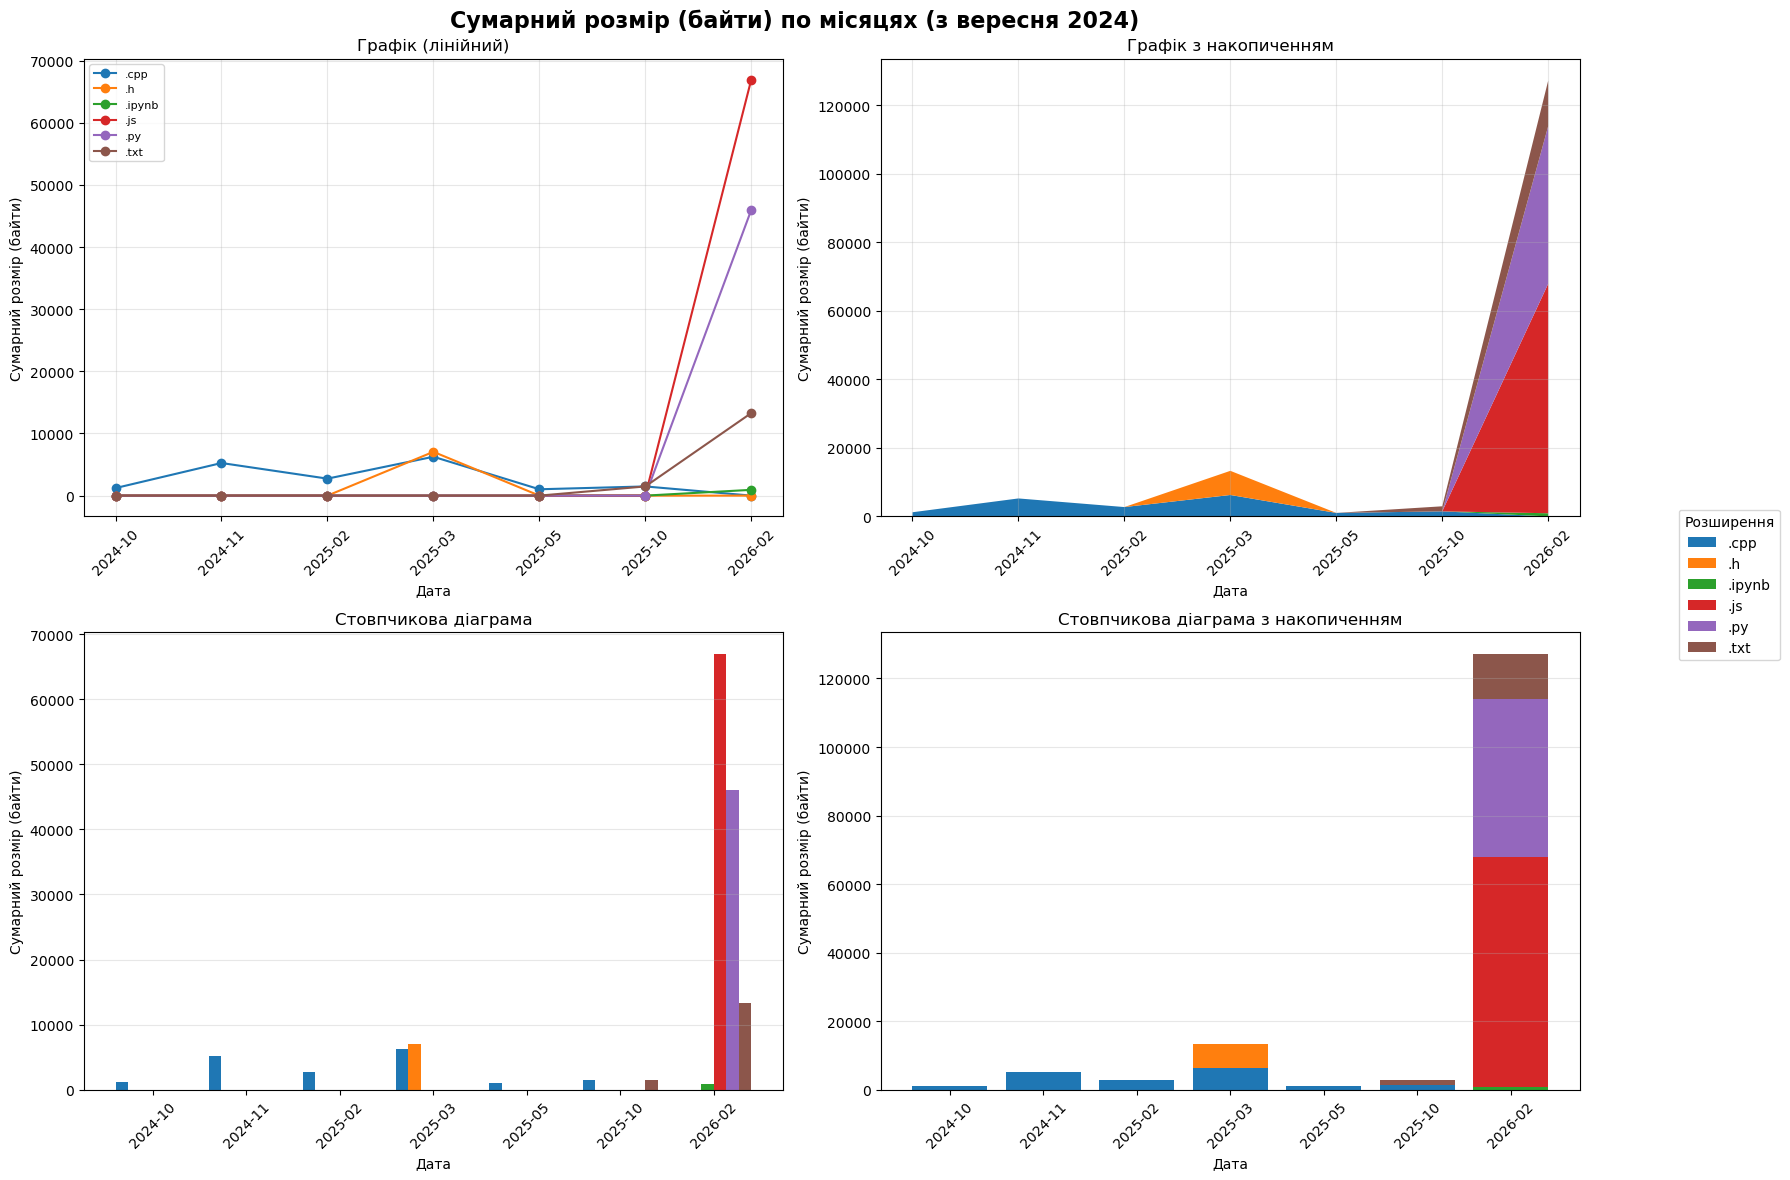

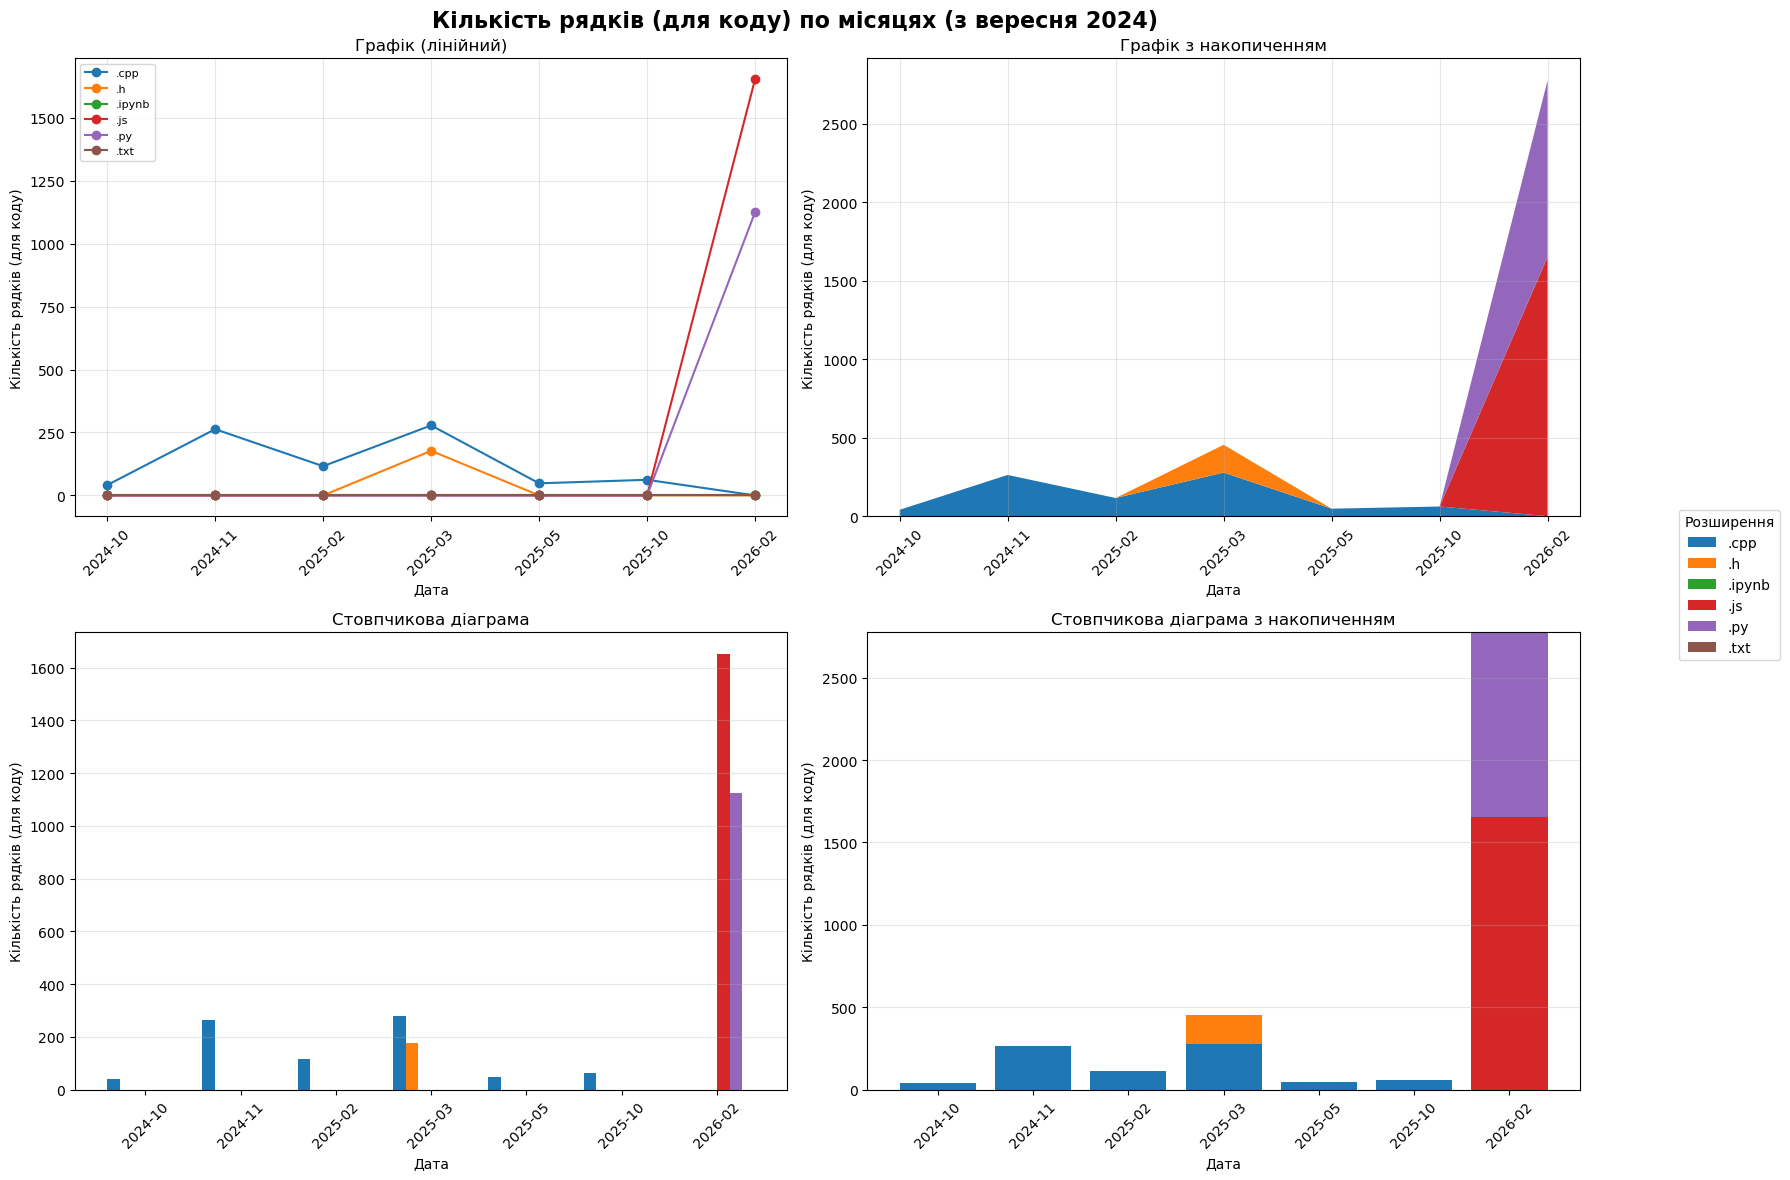

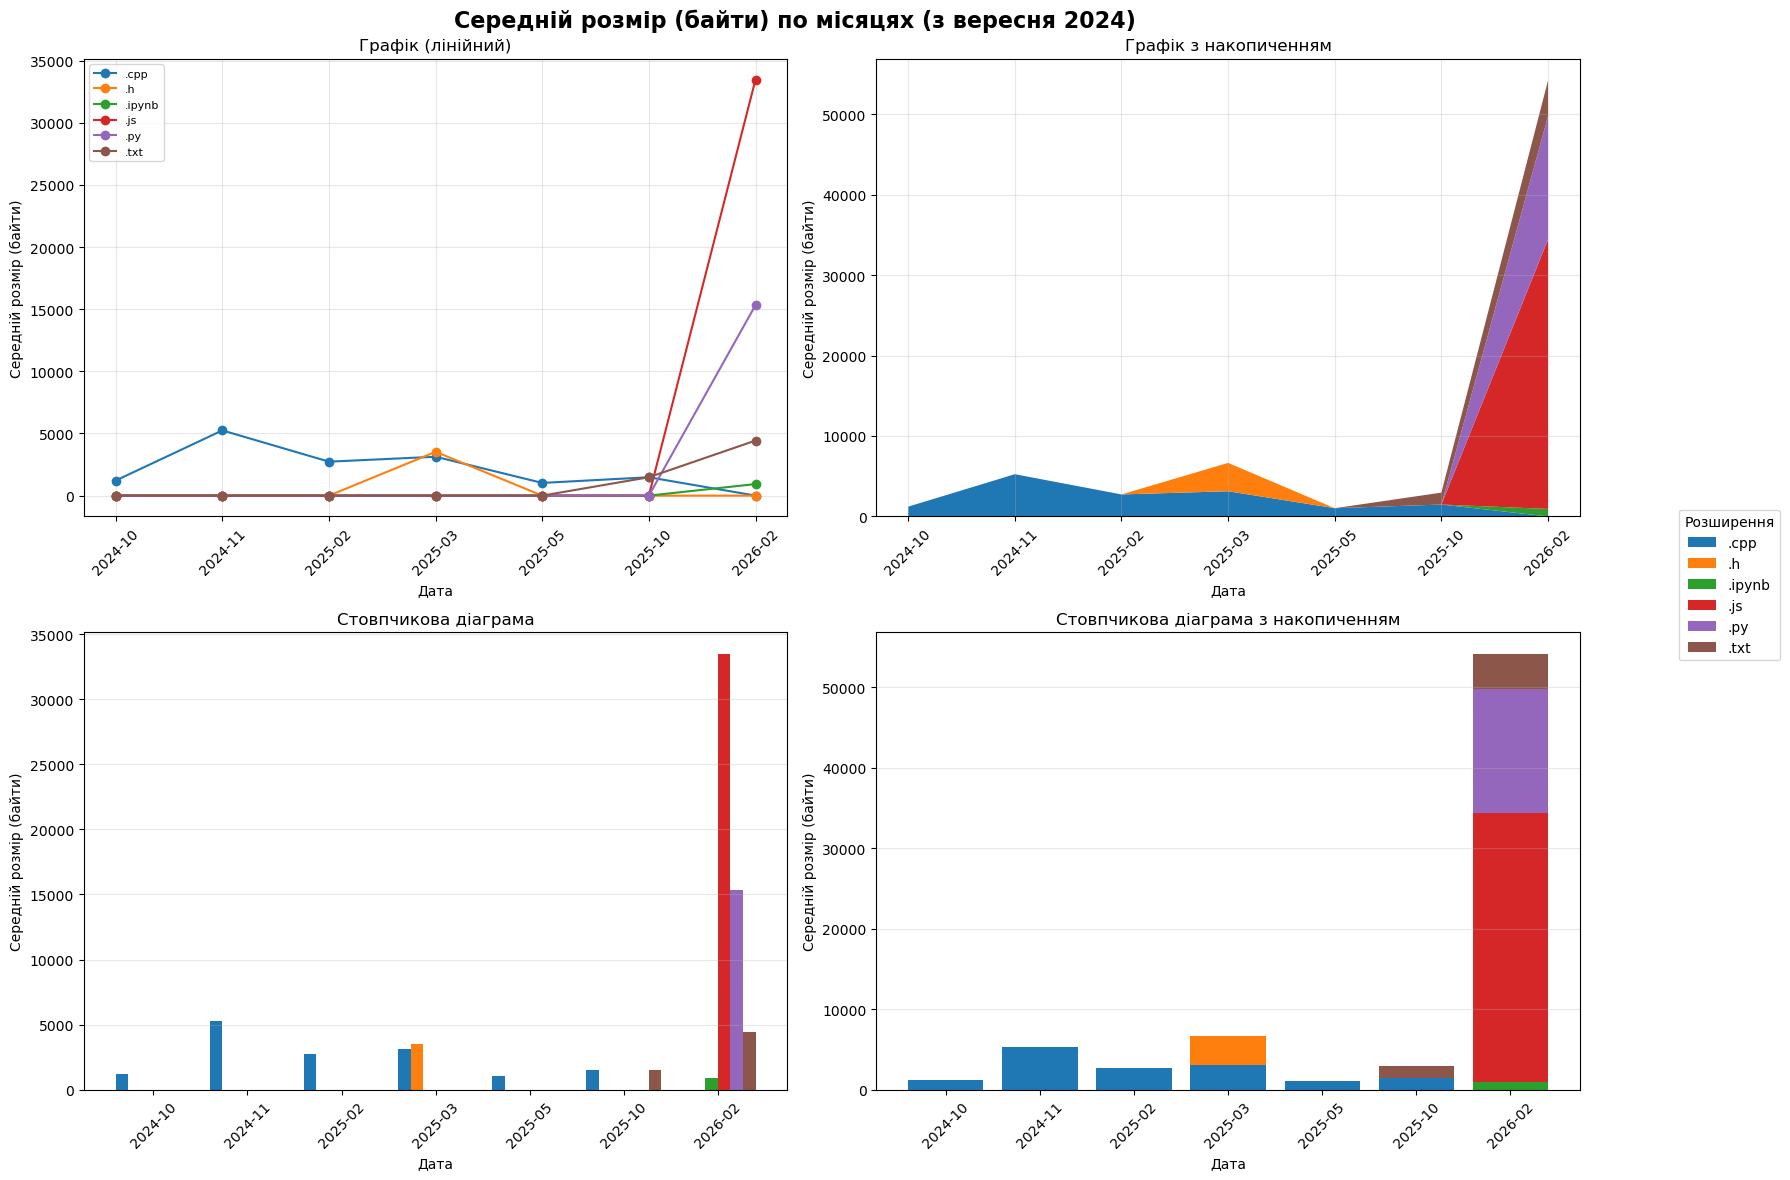

In [8]:
plot_characteristic(df_filtered, 'cnt', 'Кількість файлів')
plot_characteristic(df_filtered, 'size', 'Сумарний розмір (байти)')
plot_characteristic(df_filtered, 'lines', 'Кількість рядків (для коду)')
plot_characteristic(df_filtered_with_avg, 'avg_size', 'Середній розмір (байти)')


Агрегуємо загальну кількость файлів за розширеннями та побудуємо кругову діаграму. Для форматування відсотків використаймо лямбда-функцію з f-рядком, щоб уникнути некоректного відображення через жорстке задання формату.

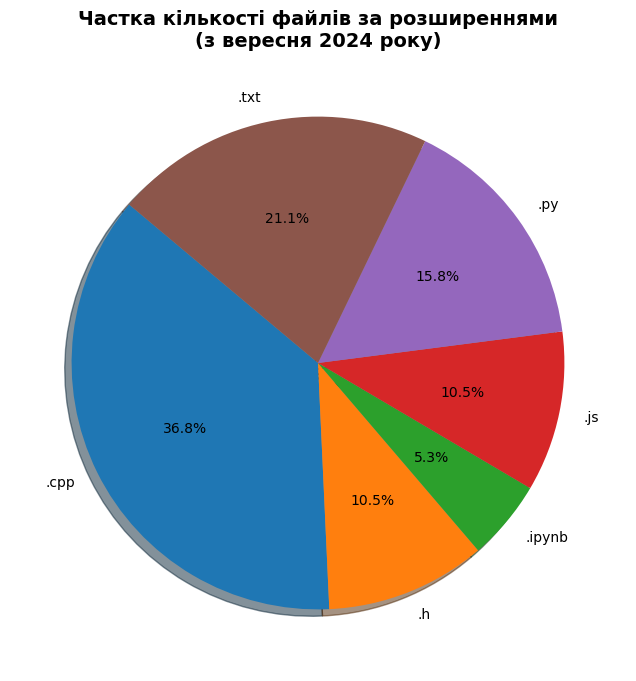

In [9]:
pie_data = df_filtered.groupby('ext')['cnt'].sum()
pie_data = pie_data[pie_data > 0]

autopct_format = lambda p: f'{p:.1f}%' if p > 0 else ''

plt.figure(figsize=(12, 8))
plt.pie(pie_data, labels=pie_data.index, autopct=autopct_format, 
        startangle=140, shadow=True)
plt.title('Частка кількості файлів за розширеннями\n(з вересня 2024 року)', 
          fontweight='bold', fontsize=14)

plt.savefig('plot_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()